## CV-LL landscape for TF (trend filtering): effect of the norm constraint

This notebook mirrors `cv_landscape_full_data_parametric_penalty.ipynb`, but for **Trend Filtering (TF)** in this repo (CVXPY implementation).

Goal: visualize the **cross-validated log-likelihood (CV-LL)** landscape over a grid of `norm_constraint` values for TF.

Key point: TF here models a **piecewise-constant log-density** over bins defined by the sorted samples, and uses a constraint
\[\|D^{(k+1)}\theta\|_1 \le C\]
with identifiability constraint \(\theta_0=0\).

Outputs:
- Per-seed CV-LL vs `norm_constraint` (optional)
- Aggregated overlay across seeds (optional)
- A simple concavity diagnostic using discrete second differences



In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from tqdm.auto import tqdm

# Ensure repo root is importable no matter where the notebook is launched from.
root = Path.cwd().resolve()
while root != root.parent and not (root / "pyproject.toml").exists():
    root = root.parent
sys.path.insert(0, str(root))

from utils.sampler.truncated_gmm import TruncatedGMM
from utils.sampler.truncated_normal import TruncatedNormal
from utils.sampler.sinusoidal import Sinusoidal
from utils.sampler.step_function import StepFunction

from methods.non_HAL_method.TF_CVXPY.estimator import TrendFilteringCVXPYEstimator

warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (10, 6)})



In [ ]:
# ----------------------------
# Experiment configuration
# ----------------------------

# DGP choice: "truncnorm", "gmm", "sinusoidal", "step", "gs5"
dgp_name = "truncnorm"

n_samples = 800

# Trend filtering order (k=0,1,2,...) used in ||D^(k+1) theta||_1 <= C
# - k=0: piecewise-constant (penalize 1st differences)
# - k=1: piecewise-linear trend in theta (penalize 2nd differences)
# In this repo's TF formulation, theta is the bin-wise log-level.
tf_k = 1

cv_folds = 5
cv_random_state = 42

# Runtime knobs
n_seeds = 5
seed_base = 2024

# Norm-constraint grid
# Tip: start modest (e.g. 30-60 points) and scale up if runtime is okay.
norm_constraints = np.linspace(0.05, 50.0, 60)

# Solver choices: "MOSEK" (fast if licensed), else try "CLARABEL" / "ECOS" / "SCS"
solver = "MOSEK"
use_secondary_solver = True

# Output prefix + cache path
_nc_min = float(np.min(norm_constraints))
_nc_max = float(np.max(norm_constraints))
_nc_n = int(len(norm_constraints))

out_prefix = (
    f"tf_cvll_full_data_{dgp_name}_n{n_samples}_k{tf_k}_seeds{n_seeds}"
    f"_nc{_nc_min:g}-{_nc_max:g}_m{_nc_n}"
)

cache_path = Path.cwd() / f"{out_prefix}.npz"
print(out_prefix)
print("cache_path=", cache_path)



tf_cvll_full_data_truncnorm_n800_k1_seeds5_nc0.05-50_m60
cache_path= /Users/houyilong/GitHub/link_HAL_MLE/tf_cvll_full_data_truncnorm_n800_k1_seeds5_nc0.05-50_m60.npz


In [ ]:
# ----------------------------
# DGP helpers
# ----------------------------

DGP_CHOICES = ["truncnorm", "gmm", "sinusoidal", "step", "gs5"]


def create_dgp(name: str):
    if name == "truncnorm":
        return TruncatedNormal(mean=0.55, std=0.12, lower=0.0, upper=1.0)

    if name == "gmm":
        return TruncatedGMM(
            components=[
                {"mean": 0.2, "std": 0.05, "lower": 0.0, "upper": 1.0},
                {"mean": 0.5, "std": 0.05, "lower": 0.0, "upper": 1.0},
                {"mean": 0.8, "std": 0.05, "lower": 0.0, "upper": 1.0},
            ],
            weights=[0.33, 0.34, 0.33],
        )

    if name == "gs5":
        # Five narrow spikes + one broad bump around 0.5, all components truncated to [0,1]
        spike_means = [0.45, 0.475, 0.50, 0.525, 0.55]
        components = [{"mean": m, "std": 0.005, "lower": 0.0, "upper": 1.0} for m in spike_means]
        components.append({"mean": 0.50, "std": 0.05, "lower": 0.0, "upper": 1.0})
        weights = [1.0 / 15.0] * 5 + [2.0 / 3.0]
        return TruncatedGMM(components=components, weights=weights)

    if name == "sinusoidal":
        return Sinusoidal()

    if name == "step":
        return StepFunction(level1=1.5, level2=0.5, breakpoint=0.4)

    raise ValueError(f"Unknown DGP: {name}. Choose from {DGP_CHOICES}")


def generate_full_data(seed: int, n: int, dgp_name: str) -> pd.DataFrame:
    rng = np.random.default_rng(int(seed))
    sampler = create_dgp(str(dgp_name))

    # Samplers in this repo generally use numpy global RNG; set it explicitly for reproducibility.
    np.random.seed(int(seed))

    x = sampler.generate_samples(int(n))
    x = np.asarray(x, dtype=float)

    # Keep in [0,1] (TF implementation assumes support [0,1] via [0, ..., 1] knots).
    x = np.clip(x, 0.0, 1.0)

    _ = rng  # keep explicit RNG creation for clarity
    return pd.DataFrame({"W1": x})



In [4]:
# ----------------------------
# CV scoring (exact TF evaluation; no interpolation)
# ----------------------------


def _tf_logZ(theta: np.ndarray, bin_widths: np.ndarray) -> float:
    """Compute log Z(theta) = log(sum_i exp(theta_i) * bin_width_i) stably."""
    theta = np.asarray(theta, dtype=float).ravel()
    bw = np.asarray(bin_widths, dtype=float).ravel()

    if theta.shape[0] != bw.shape[0]:
        raise ValueError("theta and bin_widths must have same length")

    # log(exp(theta_i)*bw_i) = theta_i + log(bw_i)
    log_terms = theta + np.log(bw)
    m = float(np.max(log_terms))
    return m + float(np.log(np.sum(np.exp(np.clip(log_terms - m, -700, 700)))))


def sum_loglik_tf(est: TrendFilteringCVXPYEstimator, points: np.ndarray) -> float:
    """Sum log-likelihood for validation points under fitted TF model."""
    if not getattr(est, "is_fitted", False):
        raise ValueError("Estimator must be fitted")

    theta = np.asarray(est.theta_hat, dtype=float).ravel()
    knots = np.asarray(est.knots, dtype=float).ravel()
    bin_widths = np.asarray(est.bin_widths, dtype=float).ravel()

    # knots has length n+2, bin_widths length n+1, theta length n+1
    if knots.shape[0] != (theta.shape[0] + 1):
        raise ValueError("Expected len(knots) == len(theta)+1")

    logZ = _tf_logZ(theta, bin_widths)

    x = np.asarray(points, dtype=float).ravel()
    # Find which bin each x belongs to using right endpoints knots[1:]
    bin_idx = np.searchsorted(knots[1:], x, side="right")
    bin_idx = np.clip(bin_idx, 0, theta.shape[0] - 1)

    logdens = theta[bin_idx] - logZ
    return float(np.sum(logdens))


def fit_tf(
    train_df: pd.DataFrame,
    *,
    k: int,
    norm_constraint: float,
    solver: str,
    tol: float = 1e-6,
    use_secondary_solver: bool = True,
) -> TrendFilteringCVXPYEstimator:
    est = TrendFilteringCVXPYEstimator(
        k=int(k),
        norm_constraint=float(norm_constraint),
        solver=str(solver),
        tol=float(tol),
        use_secondary_solver=bool(use_secondary_solver),
    )
    return est.fit(train_df)


def compute_cv_curve_one_seed(
    df: pd.DataFrame,
    *,
    norm_constraints: np.ndarray,
    k: int,
    cv_folds: int,
    cv_random_state: int,
    solver: str,
    use_secondary_solver: bool,
    verbose: bool = False,
    show_progress: bool = True,
    progress_desc: str | None = None,
) -> np.ndarray:
    """Returns CV curve: mean over folds of (sum log-lik on validation fold)."""

    kf = KFold(n_splits=int(cv_folds), shuffle=True, random_state=int(cv_random_state))
    splits = list(kf.split(df))

    cvll = np.full(len(norm_constraints), np.nan, dtype=float)

    nc_iter = norm_constraints
    if show_progress:
        nc_iter = tqdm(norm_constraints, desc=(progress_desc or "Grid"), leave=False)

    for j, nc in enumerate(nc_iter):
        fold_scores: list[float] = []

        for tr_idx, va_idx in splits:
            train_df = df.iloc[tr_idx].reset_index(drop=True)
            val_df = df.iloc[va_idx].reset_index(drop=True)
            x_val = np.asarray(val_df["W1"].values, dtype=float)

            try:
                est = fit_tf(
                    train_df,
                    k=int(k),
                    norm_constraint=float(nc),
                    solver=str(solver),
                    use_secondary_solver=bool(use_secondary_solver),
                )
                fold_scores.append(sum_loglik_tf(est, x_val))
            except Exception as e:
                fold_scores.append(float("-inf"))
                if verbose:
                    print(f"[TF] nc={nc} fold failed: {e}")

        cvll[j] = float(np.mean(fold_scores))

    return cvll



In [5]:
# ----------------------------
# Run grid search (with simple NPZ cache)
# ----------------------------

# Parallelism knob (set to 1 for serial)
# If you set n_jobs > 1, we disable per-seed inner progress bars.
n_jobs = 5

rng = np.random.default_rng(int(seed_base))
seeds = rng.integers(1, 100000, size=int(n_seeds)).tolist()

# Set True to ignore cache even if it matches.
force_recompute = False


def _cache_matches_current(z: np.lib.npyio.NpzFile) -> bool:
    try:
        cached_nc = z["norm_constraints"].astype(float)
        cached_seeds = z["seeds"].astype(int)
        cached_meta = {
            "dgp_name": str(z["dgp_name"].tolist()[0]),
            "n_samples": int(z["n_samples"].tolist()[0]),
            "tf_k": int(z["tf_k"].tolist()[0]),
            "cv_folds": int(z["cv_folds"].tolist()[0]),
        }
    except Exception:
        return False

    current_nc = np.asarray(norm_constraints, dtype=float)
    if cached_nc.shape != current_nc.shape or not np.allclose(cached_nc, current_nc, rtol=0.0, atol=0.0):
        return False

    current_meta = {
        "dgp_name": str(dgp_name),
        "n_samples": int(n_samples),
        "tf_k": int(tf_k),
        "cv_folds": int(cv_folds),
    }
    if cached_meta != current_meta:
        return False

    # We allow seed list to differ (so you can reuse cached curves per seed list).
    _ = cached_seeds
    return True


if cache_path.exists() and not force_recompute:
    z = np.load(cache_path, allow_pickle=False)
    if _cache_matches_current(z):
        print(f"Loading cache: {cache_path}")
        seeds = z["seeds"].tolist()
        cvll_mat = z["cvll"].astype(float)
    else:
        print(f"Cache exists but config changed; recomputing: {cache_path}")
        z.close()
        force_recompute = True

if (not cache_path.exists()) or force_recompute:
    print("Computing from scratch...")

    def _compute_one_seed(seed: int) -> tuple[int, np.ndarray]:
        df = generate_full_data(seed=int(seed), n=int(n_samples), dgp_name=str(dgp_name))
        cvll = compute_cv_curve_one_seed(
            df,
            norm_constraints=np.asarray(norm_constraints, dtype=float),
            k=int(tf_k),
            cv_folds=int(cv_folds),
            cv_random_state=int(cv_random_state),
            solver=str(solver),
            use_secondary_solver=bool(use_secondary_solver),
            show_progress=(n_jobs == 1),
            progress_desc=f"seed={seed}",
        )
        return int(seed), np.asarray(cvll, dtype=float)

    if n_jobs == 1:
        out = []
        for seed in tqdm(seeds, desc="Seeds"):
            out.append(_compute_one_seed(int(seed)))
    else:
        from joblib import Parallel, delayed

        out = Parallel(n_jobs=int(n_jobs), verbose=0)(
            delayed(_compute_one_seed)(int(seed))
            for seed in tqdm(seeds, desc=f"Seeds (parallel n_jobs={n_jobs})")
        )

    out_by_seed = {s: curve for (s, curve) in out}
    cvll_mat = np.vstack([out_by_seed[int(s)] for s in seeds])

    np.savez_compressed(
        cache_path,
        seeds=np.asarray(seeds, dtype=int),
        norm_constraints=np.asarray(norm_constraints, dtype=float),
        cvll=np.asarray(cvll_mat, dtype=float),
        dgp_name=np.asarray([str(dgp_name)]),
        n_samples=np.asarray([int(n_samples)]),
        tf_k=np.asarray([int(tf_k)]),
        cv_folds=np.asarray([int(cv_folds)]),
        cv_random_state=np.asarray([int(cv_random_state)]),
        solver=np.asarray([str(solver)]),
        use_secondary_solver=np.asarray([bool(use_secondary_solver)]),
        n_jobs=np.asarray([int(n_jobs)]),
    )
    print(f"Saved cache: {cache_path}")

print("Shapes:", cvll_mat.shape)



Computing from scratch...


Seeds (parallel n_jobs=5):   0%|          | 0/5 [00:00<?, ?it/s]

Saved cache: /Users/houyilong/GitHub/link_HAL_MLE/tf_cvll_full_data_truncnorm_n800_k1_seeds5_nc0.05-50_m60.npz
Shapes: (5, 60)


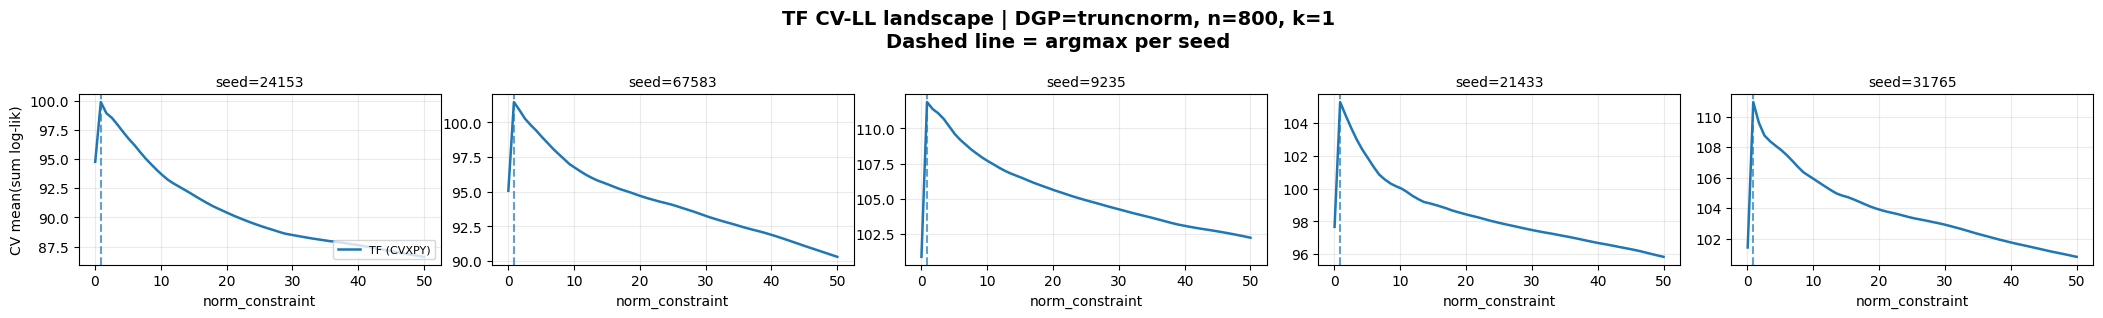

Saved: tf_cvll_full_data_truncnorm_n800_k1_seeds5_nc0.05-50_m60_seeds.png


In [6]:
# ----------------------------
# Visualization 1: per-seed CV-LL landscapes
# ----------------------------

norm_constraints_ = np.asarray(norm_constraints, dtype=float)

n_cols = 5
n_rows = (len(seeds) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.2, n_rows * 3.2))
axes = np.array(axes).reshape(-1)

for i, seed in enumerate(seeds):
    ax = axes[i]
    y_raw = np.asarray(cvll_mat[i], dtype=float)

    # If a fold fails and yields -inf, plotting can look like a flat line.
    y = np.where(np.isfinite(y_raw), y_raw, np.nan)

    ax.plot(norm_constraints_, y, color="C0", lw=1.8, label="TF (CVXPY)")

    if np.any(np.isfinite(y)):
        best_idx = int(np.nanargmax(y))
        ax.axvline(norm_constraints_[best_idx], color="C0", ls="--", alpha=0.7)

    ax.set_title(f"seed={seed}", fontsize=10)
    ax.grid(alpha=0.25)

    if i % n_cols == 0:
        ax.set_ylabel("CV mean(sum log-lik)")
    if i >= (n_rows - 1) * n_cols:
        ax.set_xlabel("norm_constraint")

# hide unused
for j in range(len(seeds), len(axes)):
    axes[j].axis("off")

axes[0].legend(fontsize=8, loc="lower right")
plt.suptitle(
    f"TF CV-LL landscape | DGP={dgp_name}, n={n_samples}, k={tf_k}\n"
    "Dashed line = argmax per seed",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(f"{out_prefix}_seeds.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {out_prefix}_seeds.png")



## Visualize the fitted density for a single seed

This plots the TF fit for one seed using the **best norm constraint from the grid search** and overlays the true density (when available).



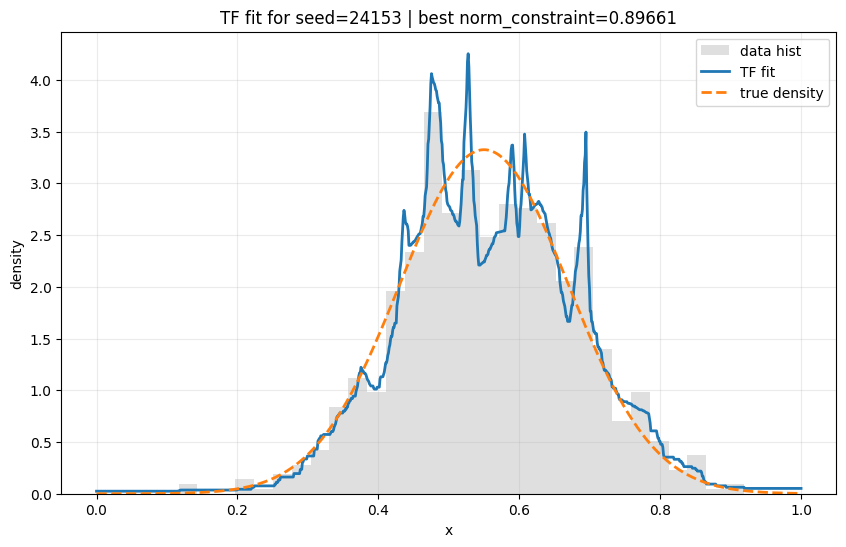

seed=24153 | best norm_constraint=0.89661


In [7]:
# ----------------------------
# Fit + visualize one seed
# ----------------------------

seed_to_show = int(seeds[0])  # change this if you want a specific seed
seed_idx = list(map(int, seeds)).index(seed_to_show)

cv_curve = np.asarray(cvll_mat[seed_idx], dtype=float)
cv_curve = np.where(np.isfinite(cv_curve), cv_curve, -np.inf)

if np.all(np.isneginf(cv_curve)):
    raise RuntimeError("All CV values are -inf for this seed; check solver failures.")

best_idx = int(np.argmax(cv_curve))
best_nc = float(norm_constraints_[best_idx])

# Fit TF at the best norm constraint for this seed
df_seed = generate_full_data(seed=int(seed_to_show), n=int(n_samples), dgp_name=str(dgp_name))
est_seed = fit_tf(
    df_seed,
    k=int(tf_k),
    norm_constraint=float(best_nc),
    solver=str(solver),
    use_secondary_solver=bool(use_secondary_solver),
)

grid, density_hat = est_seed.get_density()

# True density (all DGPs defined above implement compute_density)
sampler = create_dgp(str(dgp_name))
true_density = sampler.compute_density(grid)

plt.figure(figsize=(10, 6))
plt.hist(np.asarray(df_seed["W1"].values, dtype=float), bins=30, density=True, alpha=0.25, color="gray", label="data hist")
plt.plot(grid, density_hat, color="C0", lw=2, label="TF fit")
plt.plot(grid, true_density, color="C1", lw=2, ls="--", label="true density")
plt.title(f"TF fit for seed={seed_to_show} | best norm_constraint={best_nc:g}")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"seed={seed_to_show} | best norm_constraint={best_nc:g}")



## Optuna vs grid search (same TF + same seed)

This runs Optuna on the **same TF-CVXPY estimator** (via the `TrendFilteringADMMEstimator` alias) and **fixes k** to match the grid search, then compares the chosen `norm_constraint` and the fitted density.



[I 2026-01-17 00:10:45,770] A new study created in memory with name: no-name-23278f86-aeb7-4b19-abda-be1695449d49


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-01-17 00:10:46,037] Trial 0 finished with value: -100.43325112927171 and parameters: {'norm_constraint': 0.6646459471581082}. Best is trial 0 with value: -100.43325112927171.
[I 2026-01-17 00:10:46,259] Trial 1 finished with value: -87.97426817198057 and parameters: {'norm_constraint': 35.57238004671709}. Best is trial 0 with value: -100.43325112927171.
[I 2026-01-17 00:10:46,498] Trial 2 finished with value: -94.95680791789293 and parameters: {'norm_constraint': 7.851485442027691}. Best is trial 0 with value: -100.43325112927171.
[I 2026-01-17 00:10:46,737] Trial 3 finished with value: -98.16949994962832 and parameters: {'norm_constraint': 3.125686787260874}. Best is trial 0 with value: -100.43325112927171.
[I 2026-01-17 00:10:47,141] Trial 4 finished with value: -100.10931757544724 and parameters: {'norm_constraint': 0.14690139693517673}. Best is trial 0 with value: -100.43325112927171.
[I 2026-01-17 00:10:47,387] Trial 5 finished with value: -100.10880309537347 and parameter

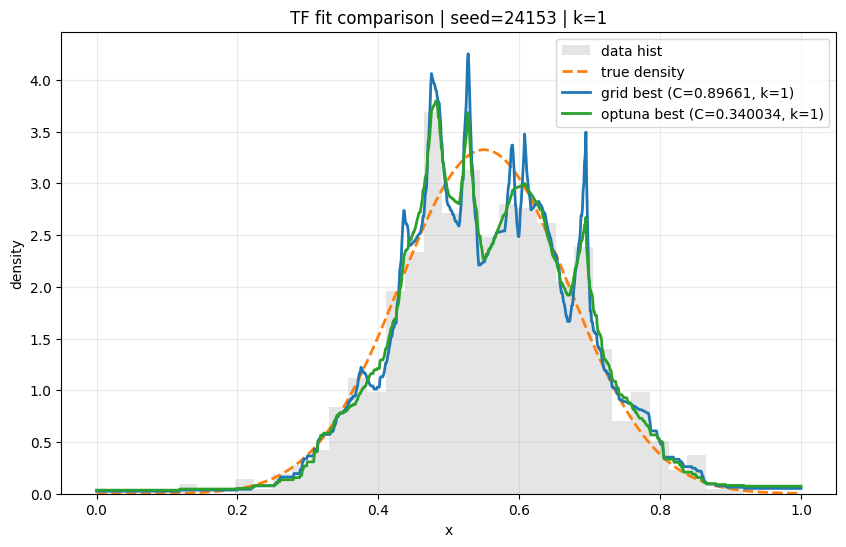

Grid-search best C:  0.89661 (k=1)
Optuna best C:       0.340034 (k=1)
Optuna trials:       30


In [8]:
# ----------------------------
# Optuna vs grid search (norm_constraint)
# ----------------------------

import optuna

optuna_trials = 30  # increase if you want a tighter search
search_k = False    # set True to let Optuna choose k in {0,1,2}


def cv_score_tf_optuna(
    df: pd.DataFrame,
    *,
    k: int,
    norm_constraint: float,
    cv_folds: int,
    cv_random_state: int,
    solver: str,
    use_secondary_solver: bool,
) -> float:
    kf = KFold(n_splits=int(cv_folds), shuffle=True, random_state=int(cv_random_state))
    scores: list[float] = []

    for tr_idx, va_idx in kf.split(df):
        train_df = df.iloc[tr_idx].reset_index(drop=True)
        val_df = df.iloc[va_idx].reset_index(drop=True)
        x_val = np.asarray(val_df["W1"].values, dtype=float)

        try:
            est = fit_tf(
                train_df,
                k=int(k),
                norm_constraint=float(norm_constraint),
                solver=str(solver),
                use_secondary_solver=bool(use_secondary_solver),
            )
            scores.append(sum_loglik_tf(est, x_val))
        except Exception:
            scores.append(float("-inf"))

    return float(np.mean(scores))


sampler_optuna = optuna.samplers.TPESampler(seed=int(cv_random_state))


def objective(trial: optuna.Trial) -> float:
    k_trial = int(trial.suggest_categorical("k", [tf_k])) if search_k else int(tf_k)
    nc = trial.suggest_float(
        "norm_constraint",
        float(np.min(norm_constraints_)),
        float(np.max(norm_constraints_)),
        log=True,
    )

    score = cv_score_tf_optuna(
        df_seed,
        k=k_trial,
        norm_constraint=nc,
        cv_folds=int(cv_folds),
        cv_random_state=int(cv_random_state),
        solver=str(solver),
        use_secondary_solver=bool(use_secondary_solver),
    )
    return -score  # maximize CV SLL


study = optuna.create_study(direction="minimize", sampler=sampler_optuna)
study.optimize(objective, n_trials=int(optuna_trials), show_progress_bar=True)

best_nc_optuna = float(study.best_params["norm_constraint"])
best_k_optuna = int(study.best_params.get("k", tf_k))

# Fit TF at the optuna-selected norm constraint (CVXPY estimator)
est_optuna = fit_tf(
    df_seed,
    k=int(best_k_optuna),
    norm_constraint=float(best_nc_optuna),
    solver=str(solver),
    use_secondary_solver=bool(use_secondary_solver),
)

grid_optuna, density_optuna = est_optuna.get_density()
true_density_optuna = sampler.compute_density(grid_optuna)

# Align grid-search fit to optuna grid for overlay
if not np.allclose(grid, grid_optuna):
    density_grid = np.interp(grid_optuna, grid, density_hat)
else:
    density_grid = density_hat

plt.figure(figsize=(10, 6))
plt.hist(np.asarray(df_seed["W1"].values, dtype=float), bins=30, density=True, alpha=0.2, color="gray", label="data hist")
plt.plot(grid_optuna, true_density_optuna, color="C1", lw=2, ls="--", label="true density")
plt.plot(grid_optuna, density_grid, color="C0", lw=2, label=f"grid best (C={best_nc:g}, k={tf_k})")
plt.plot(grid_optuna, density_optuna, color="C2", lw=2, label=f"optuna best (C={best_nc_optuna:g}, k={best_k_optuna})")
plt.title(f"TF fit comparison | seed={seed_to_show} | k={tf_k}")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"Grid-search best C:  {best_nc:g} (k={tf_k})")
print(f"Optuna best C:       {best_nc_optuna:g} (k={best_k_optuna})")
print(f"Optuna trials:       {optuna_trials}")



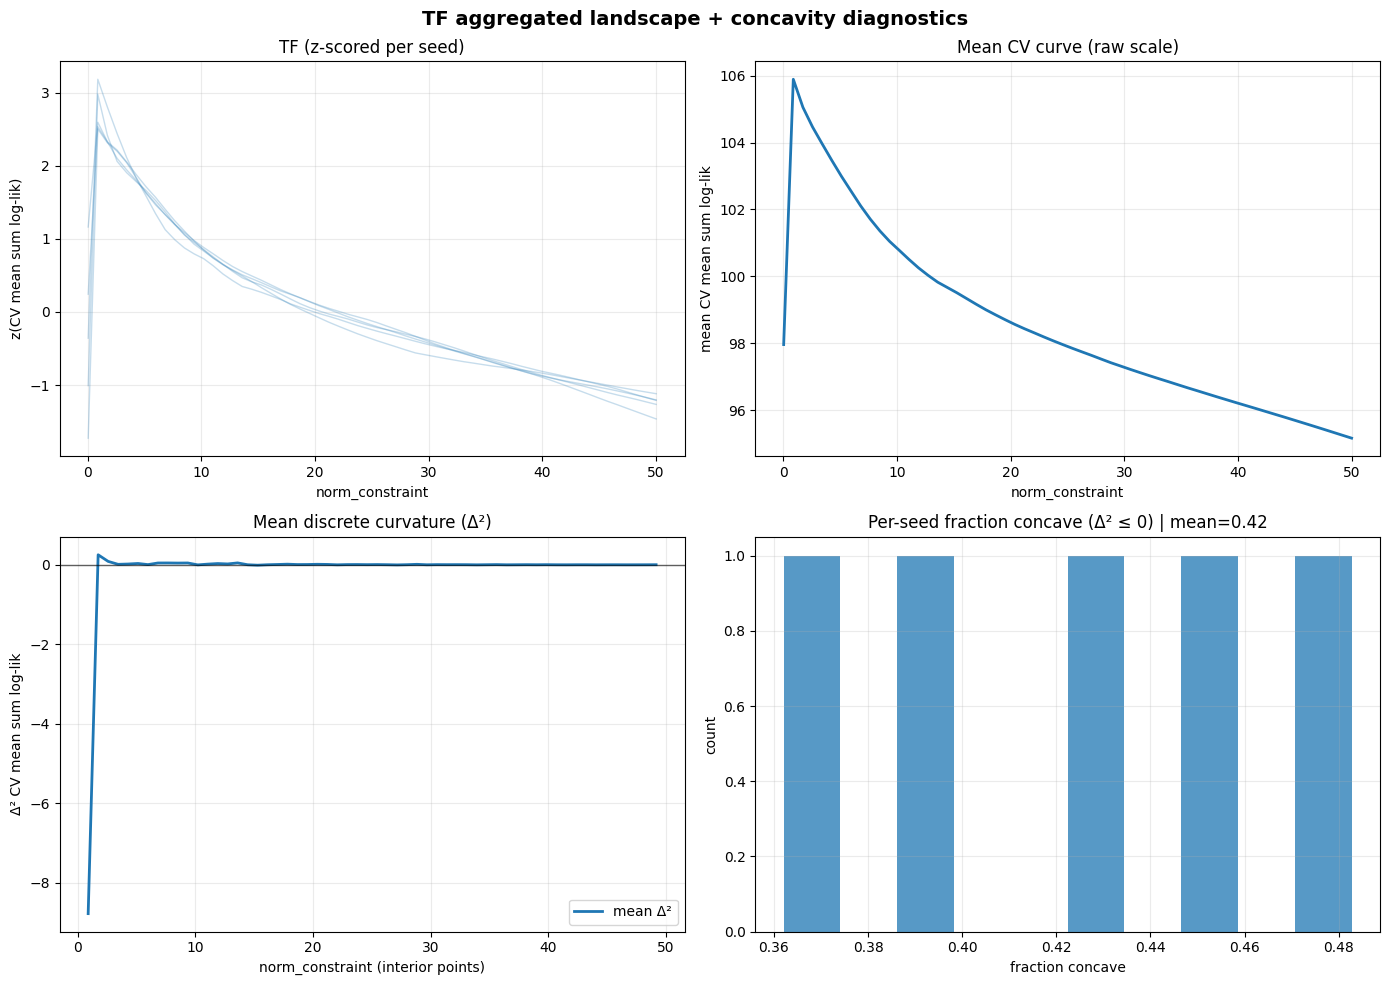

Saved: tf_cvll_full_data_truncnorm_n800_k1_seeds5_nc0.05-50_m60_aggregated.png


In [9]:
# ----------------------------
# Visualization 2: aggregated overlays + concavity proxy
# ----------------------------


def zscore_rows(Y: np.ndarray) -> np.ndarray:
    mu = np.nanmean(Y, axis=1, keepdims=True)
    sd = np.nanstd(Y, axis=1, keepdims=True)
    sd = np.where(sd > 0, sd, 1.0)
    return (Y - mu) / sd

Y = np.asarray(cvll_mat, dtype=float)
Z = zscore_rows(np.where(np.isfinite(Y), Y, np.nan))

# Discrete second difference (curvature proxy): concave if <= 0
# Shapes: (n_seeds, n_grid-2)
d2 = np.diff(Y, n=2, axis=1)
frac_concave = np.mean(d2 <= 0, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for r in range(Z.shape[0]):
    ax.plot(norm_constraints_, Z[r], color="C0", alpha=0.25, lw=1.0)
ax.set_title("TF (z-scored per seed)")
ax.set_xlabel("norm_constraint")
ax.set_ylabel("z(CV mean sum log-lik)")
ax.grid(alpha=0.25)

ax = axes[0, 1]
ax.plot(norm_constraints_, np.nanmean(Y, axis=0), color="C0", lw=2)
ax.set_title("Mean CV curve (raw scale)")
ax.set_xlabel("norm_constraint")
ax.set_ylabel("mean CV mean sum log-lik")
ax.grid(alpha=0.25)

ax = axes[1, 0]
ax.plot(norm_constraints_[1:-1], np.mean(d2, axis=0), color="C0", lw=2, label="mean Δ²")
ax.axhline(0, color="k", lw=1, alpha=0.6)
ax.set_title("Mean discrete curvature (Δ²)")
ax.set_xlabel("norm_constraint (interior points)")
ax.set_ylabel("Δ² CV mean sum log-lik")
ax.grid(alpha=0.25)
ax.legend()

ax = axes[1, 1]
ax.hist(frac_concave, bins=10, alpha=0.75, color="C0")
ax.set_title(f"Per-seed fraction concave (Δ² ≤ 0) | mean={frac_concave.mean():.2f}")
ax.set_xlabel("fraction concave")
ax.set_ylabel("count")
ax.grid(alpha=0.25)

plt.suptitle("TF aggregated landscape + concavity diagnostics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{out_prefix}_aggregated.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {out_prefix}_aggregated.png")

